<a href="https://colab.research.google.com/github/pmanideep20/Machine-Learning/blob/main/STUDENT_PERFORMACE_PREDICTOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ML PROJECT**


## **Load Data**

In [ ]:
#Installing Kaggle
!pip install kaggle

In [ ]:
#Uploading Kaggle from files
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"manideepchowdary20","key":"8001d2122b8f55018a4d22b1be40e2f0"}'}

In [ ]:
#Kaggle Directory
!mkdir ~/.kaggle

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
#Copying Kaggle.json file
!cp kaggle.json ~/.kaggle/

In [ ]:
ls -ltr ~/.kaggle/

total 4
-rw------- 1 root root 74 May 27 07:55 kaggle.json


In [ ]:
#To correct the permissions
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#List down all data sets
!kaggle datasets list

ref                                                                title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  ------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                     Social Media Impact on Teen Mental Health              16190  2026-04-05 08:04:21.823000          34831        729                1  
laveshjadon/ai-impact-on-students                                  Impact of Ai on Students                             1187170  2026-05-10 23:12:10.070000           3454         81                1  
shambhurajejagadale/student-performance-prediction-dataset         Student Performance Prediction Dataset                 84282  2026-05-09 15:49:58.877000           2899         69               

In [ ]:
!kaggle datasets list -s 'Student_performance_data.csv'

ref                                                 title                                        size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------  -------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
waqi786/student-performance-dataset                 📚 Student Performance Dataset 📚              6061  2024-07-26 04:24:34.810000           7806         88                1  
borovai0/student-performance-analytics-dataset      Student Performance Analytics Dataset      264103  2026-04-01 19:54:36.470000           3685         68                1  
muhammadazam121/student-performance-data            student-performance-data                    67739  2025-06-14 04:11:38.953000           3259         50                1  
nohahasan007/student-performance-analytics-dataset  Student Performance Analytics Dataset      264103  2026-04-12 13:47:16.26

In [ ]:
!kaggle datasets download -d 'muhammadazam121/student-performance-data' -p ../data/KaggleDatasetforStudentPerformance

Dataset URL: https://www.kaggle.com/datasets/muhammadazam121/student-performance-data
License(s): Attribution 4.0 International (CC BY 4.0)
100% 66.2k/66.2k [00:00<00:00, 82.6MB/s]



In [ ]:
ls-ltr ../data/KaggleDatasetforStudentPerformance

total 232
-rw-r--r-- 1 root root  67739 Jun 14  2025 student-performance-data.zip
-rwxrwxrwx 1 root root 166901 Jun 14  2025 Student_performance_data.csv*


In [ ]:
!unzip ../data/KaggleDatasetforStudentPerformance/student-performance-data.zip -d ../data/KaggleDatasetforStudentPerformance

Archive:  ../data/KaggleDatasetforStudentPerformance/student-performance-data.zip
  inflating: ../data/KaggleDatasetforStudentPerformance/Student_performance_data.csv  


In [ ]:
!chmod 777 ../data/KaggleDatasetforStudentPerformance/Student_performance_data.csv

In [ ]:
import pandas as pd
df = pd.read_csv('../data/KaggleDatasetforStudentPerformance/Student_performance_data.csv')
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


## **Data Preparation**

### **Data seperation**

In [ ]:
y = df['GPA']
y

,GPA
0,2.929196
1,3.042915
2,0.112602
3,2.054218
4,1.288061
...,...
2387,3.455509
2388,3.279150
2389,1.142333
2390,1.803297


In [ ]:
x = df.drop('GPA', axis = 1)
x

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,0.0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,4.0
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,2.0
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.0


### **Data splitting**

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 100)

In [ ]:
x_train

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GradeClass
1007,2008,15,1,1,2,19.916047,1,0,2,0,0,0,0,1.0
30,1031,15,0,2,2,5.055317,12,1,0,0,1,0,0,4.0
1121,2122,17,1,2,2,12.888463,17,0,2,0,1,0,0,4.0
1131,2132,16,1,0,0,6.754960,0,0,2,1,0,0,0,1.0
2277,3278,16,1,1,2,3.778596,4,0,3,1,0,0,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350,1351,18,0,0,4,11.707508,17,0,0,0,0,1,0,4.0
1930,2931,18,1,1,3,2.894213,27,0,2,0,0,1,0,4.0
79,1080,18,1,3,1,11.046760,25,0,3,0,1,0,0,4.0
1859,2860,15,1,0,3,14.391168,21,0,2,0,0,1,1,4.0


In [ ]:
x_test

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GradeClass
474,1475,17,1,1,2,1.444587,24,0,0,0,0,0,0,4.0
939,1940,16,1,2,1,5.609264,12,0,4,0,0,0,0,3.0
231,1232,18,1,3,1,19.413361,25,0,2,0,0,0,0,4.0
2255,3256,18,0,0,2,3.777404,13,0,2,0,0,0,0,2.0
1909,2910,15,1,3,3,2.764642,13,0,3,1,0,0,0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1140,2141,16,1,0,1,17.338821,12,0,3,1,0,1,0,2.0
1417,2418,17,1,0,2,18.144863,11,0,3,0,0,0,0,3.0
328,1329,18,1,2,2,11.136367,22,0,0,0,0,0,0,4.0
1705,2706,18,1,0,2,8.858282,0,1,4,1,0,0,0,0.0


In [ ]:
y_train

,GPA
1007,3.130223
30,1.727120
1121,1.591366
1131,3.294332
2277,2.897355
...,...
350,1.086151
1930,0.286110
79,0.994325
1859,1.554113


In [ ]:
y_test

,GPA
474,0.000000
939,2.102542
231,0.676818
2255,1.273818
1909,1.467968
...,...
1140,2.622179
1417,2.340372
328,1.011253
1705,4.000000


## **Model Building**

### **Linear regression**

#### **Training the model**

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

#### **Applying the model to make prediction**

In [ ]:
y_lr_train_pred = lr.predict(x_train)
y_lr_test_pred = lr.predict(x_test)

In [ ]:
y_lr_train_pred

array([3.34541274, 1.85242053, 1.64650362, ..., 0.98560323, 1.28855986,
       1.17381044])

In [ ]:
y_lr_test_pred

array([0.22827775, 2.08769779, 0.8858599 , 1.70220307, 1.89305116,
       0.26586243, 2.88593027, 2.23250286, 1.84909896, 2.73972308,
       2.47309696, 0.5696517 , 1.65282283, 3.44544347, 1.09781912,
       1.51763136, 2.30439301, 1.48594628, 0.79317559, 1.32909552,
       1.07872519, 0.68761738, 1.23034126, 0.91945938, 0.31637556,
       2.5081448 , 0.36114371, 1.29769025, 2.65874496, 3.04060377,
       1.4908403 , 0.79512696, 0.77210148, 1.55685474, 1.42300231,
       1.61300047, 1.61833192, 2.11207875, 0.84478067, 1.13979784,
       1.36789805, 2.37171516, 2.33201342, 1.99540018, 2.58656005,
       2.64119104, 1.63122185, 3.28959466, 2.67173744, 3.27179746,
       3.03961058, 2.43473966, 1.39400669, 2.11457298, 2.60218159,
       1.98457538, 3.4158643 , 2.89878337, 0.86063896, 0.52111779,
       1.66046094, 0.41701087, 1.58565627, 1.13349409, 0.76356931,
       2.52239848, 2.91744794, 1.05773953, 3.3305257 , 0.14155187,
       3.36317945, 1.61648653, 2.8809188 , 2.73290258, 2.85673

#### **Evaluating model performance**

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
lr_train_mse = mean_squared_error(y_train, y_lr_train_pred)
lr_train_r2 = r2_score(y_train, y_lr_train_pred)

lr_test_mse = mean_squared_error(y_test, y_lr_test_pred)
lr_test_r2 = r2_score(y_test, y_lr_test_pred)

In [ ]:
lr_results = pd.DataFrame(['Linear regression', lr_train_mse, lr_train_r2, lr_test_mse, lr_test_r2]).transpose()
lr_results

,0,1,2,3,4
0,Linear regression,0.035252,0.957677,0.039097,0.954222


In [ ]:
lr_results.columns = ['Method', 'Training MSE', 'Training R2', 'Test MSE', 'Test R2']
lr_results

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Linear regression,0.035252,0.957677,0.039097,0.954222


### **Random Forest**

#### **Training the model**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(max_depth = 2, random_state = 100)
rf.fit(x_train, y_train)

RandomForestRegressor(max_depth=2, random_state=100)

#### **Applying the model to make prediction**

In [ ]:
y_rf_train_pred = rf.predict(x_train)
y_rf_test_pred = rf.predict(x_test)

In [ ]:
y_rf_train_pred

array([2.97846872, 2.1184302 , 1.50988613, ..., 0.79722787, 1.50268974,
       1.50988613])

In [ ]:
y_rf_test_pred

array([0.80397667, 2.12415304, 0.79722787, 2.97071209, 2.1184302 ,
       0.79722787, 2.97846872, 2.12415304, 2.1184302 , 2.97846872,
       2.12415304, 0.80397667, 2.1184302 , 2.97846872, 1.50988613,
       1.50988613, 2.12415304, 1.50988613, 0.79722787, 1.89861964,
       0.79722787, 0.79722787, 0.80397667, 0.79722787, 0.79722787,
       2.1184302 , 0.79722787, 1.50268974, 2.97846872, 2.97846872,
       1.50988613, 0.80397667, 0.79722787, 1.51560897, 0.80397667,
       1.50988613, 1.50988613, 1.52980146, 0.79722787, 0.80397667,
       1.50988613, 2.13190967, 2.44098888, 2.1184302 , 2.97071209,
       2.97846872, 1.50988613, 2.97846872, 2.97846872, 2.97846872,
       2.97846872, 2.13190967, 0.80397667, 2.12415304, 2.97071209,
       2.44098888, 2.97846872, 2.97846872, 0.79722787, 0.79722787,
       0.81693922, 0.79722787, 2.1184302 , 0.80397667, 0.79722787,
       2.97846872, 2.97846872, 0.81019041, 2.97846872, 0.79722787,
       2.97846872, 2.1184302 , 2.97846872, 2.97846872, 2.97846

#### **Evaluating model performance**

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
rf_train_mse = mean_squared_error(y_train, y_rf_train_pred)
rf_train_r2 = r2_score(y_train, y_rf_train_pred)

rf_test_mse = mean_squared_error(y_test, y_rf_test_pred)
rf_test_r2 = r2_score(y_test, y_rf_test_pred)

In [ ]:
rf_results = pd.DataFrame(['Random Forest', rf_train_mse, rf_train_r2, rf_test_mse, rf_test_r2]).transpose()
rf_results.columns = ['Method', 'Training MSE', 'Training R2', 'Test MSE', 'Test R2']
rf_results

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Random Forest,0.140214,0.831662,0.167847,0.803471


### **Model Comparision**

In [ ]:
df_models = pd.concat([lr_results, rf_results], axis = 0)
df_models.reset_index(drop = True)

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Linear regression,0.035252,0.957677,0.039097,0.954222
1,Random Forest,0.140214,0.831662,0.167847,0.803471


## **Data Visualization**

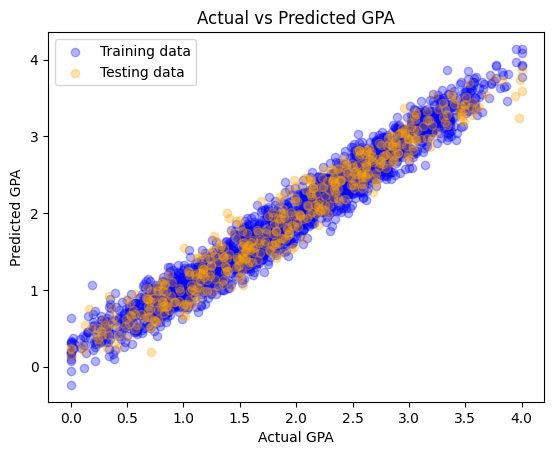

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(x= y_train,y = y_lr_train_pred, c = 'blue', label = 'Training data',alpha = 0.3)
plt.scatter(x= y_test,y = y_lr_test_pred, c = 'orange', label = 'Testing data',alpha = 0.3)
plt.xlabel('Actual GPA')
plt.ylabel('Predicted GPA')
plt.title('Actual vs Predicted GPA')
plt.legend()
plt.show()

# **PROJECT OVERVIEW**

### This project focuses on predicting student academic performance (GPA) using Machine Learning techniques. The dataset was obtained from Kaggle and preprocessed using Pandas. The GPA column was selected as the target variable, while the remaining student-related features were used as input variables. The dataset was split into training and testing sets to evaluate model performance. Two regression algorithms, Linear Regression and Random Forest Regressor, were implemented and compared using Mean Squared Error (MSE) and R² Score metrics. The project also includes data visualization to compare actual and predicted GPA values, providing insights into the accuracy of the models. The objective of this project is to explore how machine learning can be used to analyze student data and predict academic outcomes effectively.
